In [1]:
from merge_directbc_npz import merge_directbc_npz
n_nodes = 3
if n_nodes == 3:
    data1_npz = "../experiment_data/slinky_final_data/3_noded/n3_traj1_dataset_52_pts.npz"
    data2_npz = "../experiment_data/slinky_final_data/3_noded/n3_traj2_dataset_12_pts_reversed.npz"
    output_npz = "../experiment_data/slinky_final_data/3_noded/merged12_dataset.npz"
elif n_nodes == 5:
    data1_npz = "../experiment_data/slinky_final_data/5_noded/n5_traj1_dataset_52_pts.npz"
    data2_npz = "../experiment_data/slinky_final_data/5_noded/n5_traj2_dataset_12_pts_reversed.npz"
    output_npz = "../experiment_data/slinky_final_data/5_noded/merged12_dataset.npz"


In [2]:
if n_nodes == 3:
    z_offset1 = 0.0
    z_offset2 = 0.015
    skip_first_z_offset2 = True
    skip_second_z_offset2 = False
    freeze_node1_x=False
elif n_nodes == 5:
    z_offset1 = 0.0
    z_offset2 = 0.015
    skip_first_z_offset2 = True
    skip_second_z_offset2 = True
    freeze_node1_x=True


merge_directbc_npz(
    data1_npz,
    data2_npz,
    output_npz,
    mode="trim_traj1",
    overlap_tol=1e-9,
    reference_traj=0,
    recompute_lambdas=True,
    compressed=False,
    z_offset1=z_offset1,
    z_offset2=z_offset2,
    skip_first_z_offset2=skip_first_z_offset2,
    skip_second_z_offset2=skip_second_z_offset2,
    freeze_node1_x=freeze_node1_x
)

# check the merged file
import numpy as np
data = np.load(output_npz)
qs = data["qs"]
print(qs.shape)


(1, 51, 11)


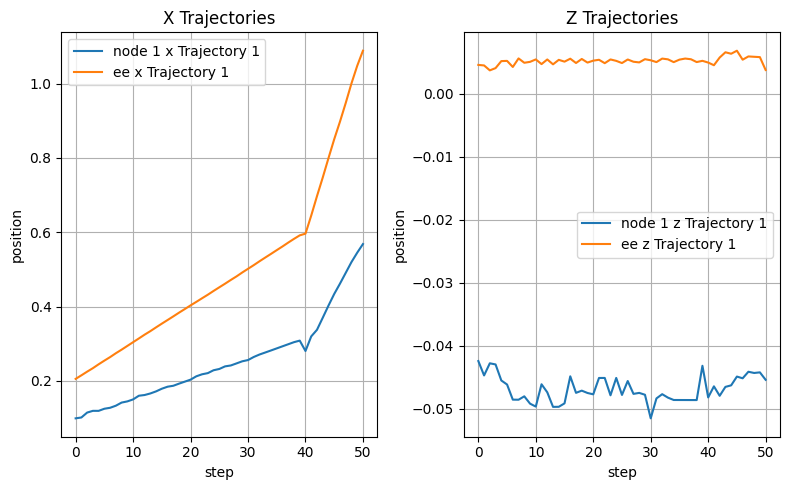

In [3]:
import matplotlib.pyplot as plt

n_nodes = (qs.shape[2] + 1) // 4
center_node = n_nodes//2 
for i in range(qs.shape[0]):
    # separate sublots for x trajectories and z trajectories
    plt.figure(figsize=(8, 5))
    # plot x trajectories
    plt.subplot(1, 2, 1)
    plt.plot(qs[i, :, center_node*4], label=f"node {center_node} x Trajectory {i+1}")
    plt.plot(qs[i, :, -3], label=f"ee x Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("X Trajectories")
    plt.legend()
    plt.grid()

    # plot z trajectories
    plt.subplot(1, 2, 2)
    plt.plot(qs[i, :, center_node*4 + 2], label=f"node {center_node} z Trajectory {i+1}")
    plt.plot(qs[i, :, -1], label=f"ee z Trajectory {i+1}")
    plt.xlabel("step")
    plt.ylabel("position")
    plt.title("Z Trajectories")
    plt.legend()
    plt.grid()
    plt.tight_layout()
    plt.show()

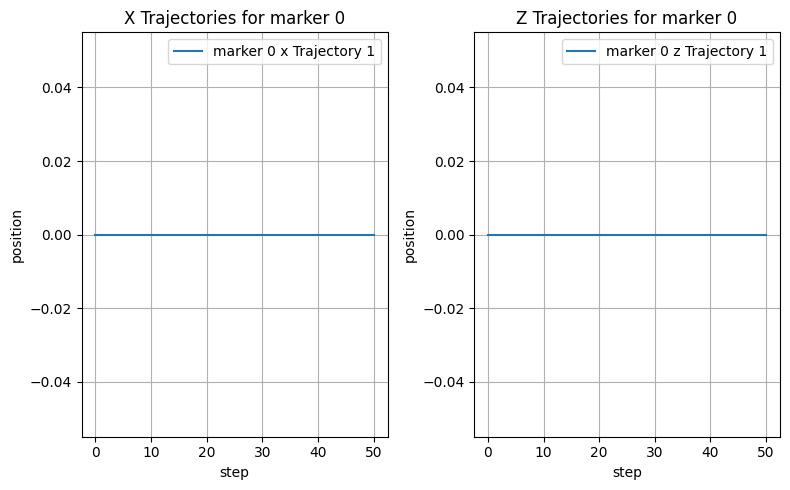

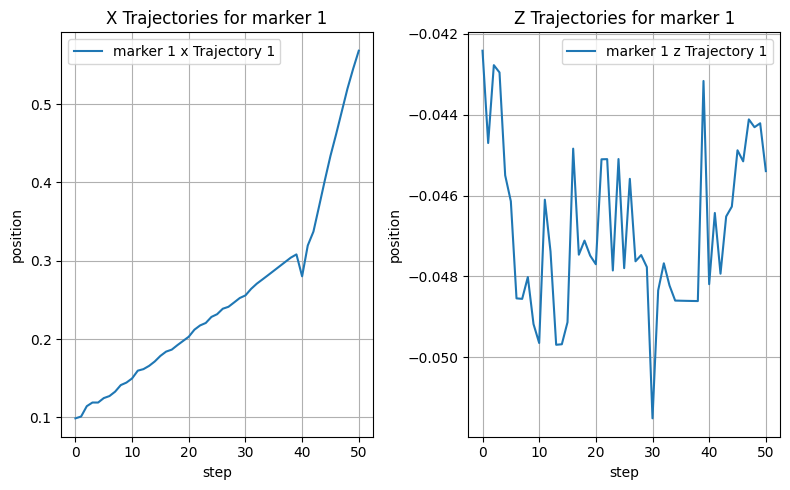

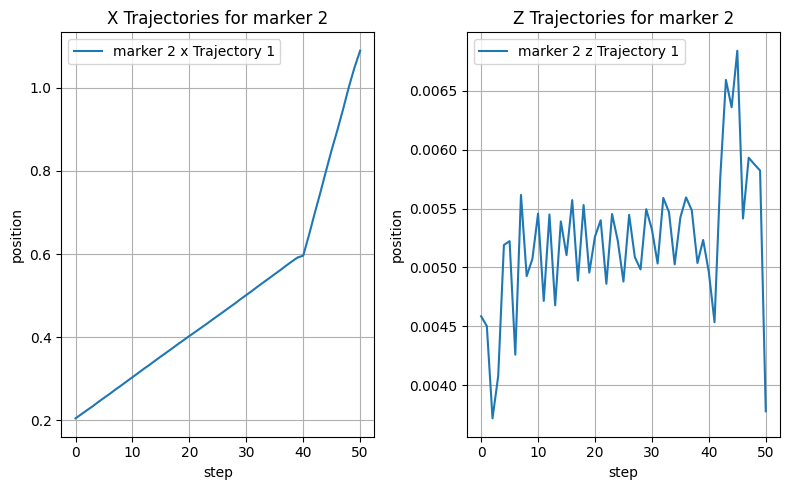

In [4]:
# similarly plot x and z trajectories for all the nodes
for i in range(qs.shape[0]):   
    for node in range(n_nodes):
        plt.figure(figsize=(8, 5))
        # plot x trajectories
        plt.subplot(1, 2, 1)
        plt.plot(qs[i, :, node*4], label=f"marker {node} x Trajectory {i+1}")
        plt.xlabel("step")
        plt.ylabel("position")
        plt.title(f"X Trajectories for marker {node}")
        plt.legend()
        plt.grid()

        # plot z trajectories
        plt.subplot(1, 2, 2)
        plt.plot(qs[i, :, node*4 + 2], label=f"marker {node} z Trajectory {i+1}")
        plt.xlabel("step")
        plt.ylabel("position")
        plt.title(f"Z Trajectories for marker {node}")
        plt.legend()
        plt.grid()
        plt.tight_layout()
        plt.show()